# 13 — Diagnostics: positive control at production settings

**Purpose:** Re-test the canonical positive control **KRT8 × KRT18** at two permutation counts — `n_sim = 99` (matches the nb04 / nb10 validation regime) and `n_sim = 199` (matches the production HPC run that produced the near-empty network in nb12) — using the **production concave-hull window and edge correction** for both.

## The question this notebook answers

The 438-row HPC output passes only 1 of 438 pairs through the `n_consec=3` filter. Two non-failure explanations are on the table (see `notes/notebook_audit.md` Outstanding Issues):

1. **`n_sim` mismatch.** With 199 permutations the pointwise envelope width is roughly 2× the false-positive tolerance of the 99-permutation envelope (alpha ≈ 0.005 per side vs ≈ 0.01). If KRT8×KRT18 — known to clear the envelope at `n_sim=99` — *also* clears it at `n_sim=199` then the envelope width isn't the problem.
2. **Panel scope.** The CellChatDB panel excludes the strong co-expression pairs by construction. Addressed separately in `extended_panel_rationale.md` (Step B of the revival plan).

This notebook isolates (1). One observed `L(r)` curve, two permutation envelopes, one plot.

## Why strip 2?

In nb04, KRT8×KRT18 showed the strongest excursion on strip 2 (the infected strip). Using strip 2 keeps the comparison apples-to-apples with the regime where validation succeeded. A strip-1 and strip-3 retest is a cheap follow-up if needed; not the cheapest first move.

**Methodological choices flagged for sensitivity analysis later:**
- `SEED=42` fixed — for a defensible publication figure, repeat with 5 seeds.
- `r_vals` matches the production two-segment grid (dense in 5–50 px, coarser to 250 px).
- The concave-hull window uses `ratio=0.1`, the production setting (nb09).

**Outputs:**
- `results/figures/13_positive_anchor_retest.png` (figure R10 in the tracker)
- Printed verdict: does each `n_sim` pass the `n_consec≥3` significance criterion?

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load the shared function library (bivariate_k, k_to_l, compute_envelope,
# get_window, get_coords, run_pair_analysis, ...). This is the same
# library used by the HPC batch script, so behaviour matches production.
%run 00_functions.ipynb

DATA   = Path('../data/processed/s1_all_strips_cleaned.parquet')
FIGS   = Path('../results/figures')
FIGS.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 110

In [2]:
# ── Parameters (all production settings, locked from nb10 / HPC scripts) ──

# Pair under test
GENE_A, GENE_B = 'KRT8', 'KRT18'
STRIP          = 'strip_2'

# Radii: two-segment grid matching nb10 production
R_MIN, R_CC, R_MAX = 5, 50, 250
N_CC, N_COARSE     = 30, 20
r_cc_vals     = np.linspace(R_MIN, R_CC,  N_CC)
r_coarse_vals = np.linspace(R_CC,  R_MAX, N_COARSE + 1)[1:]
r_vals        = np.concatenate([r_cc_vals, r_coarse_vals])
assert len(r_vals) == 50

# Window and edge correction: production concave hull
WINDOW_TYPE   = 'concave'
CONCAVE_RATIO = 0.1
RESOLUTION    = 64

# The two regimes we want to compare
N_SIM_VALUES = [99, 199]
SEED         = 42

# Significance criterion used by nb12 (sustained pointwise exceedance)
N_CONSEC = 3

# Subsample cap for high-abundance genes. No-op when min(n_a, n_b) <= MAX_N,
# so the positive control (KRT8=675, KRT18=960) is unaffected. Triggers only
# for the MALAT1 negative control in section 7 (16,808 transcripts), where
# the per-pair Shapely edge correction would otherwise dominate runtime.
# Must be passed to both the observed bivariate_k and the compute_envelope
# call with the same SEED so they see the same subset.
MAX_N = 3000

print(f'Test pair:   {GENE_A} × {GENE_B}  on  {STRIP}')
print(f'r_vals:      {len(r_vals)} points from {r_vals[0]:.0f} to {r_vals[-1]:.0f} px')
print(f'Window:      {WINDOW_TYPE} (ratio={CONCAVE_RATIO}), resolution={RESOLUTION}')
print(f'Comparing:   n_sim ∈ {N_SIM_VALUES}, seed={SEED}, n_consec={N_CONSEC}')
print(f'Subsample:   max_n={MAX_N} (applied in §7 only)')

Test pair:   KRT8 × KRT18  on  strip_2
r_vals:      50 points from 5 to 250 px
Window:      concave (ratio=0.1), resolution=64
Comparing:   n_sim ∈ [99, 199], seed=42, n_consec=3
Subsample:   max_n=3000 (applied in §7 only)


## 1. Load and filter the cleaned data

Apply the same three QC masks used by the production pipeline: drop DBSCAN-flagged noise, small-cluster artefacts, and manually-excluded clusters. This is the same filter that `batch_k_analysis.py` applies before computing K functions.

In [3]:
df_raw = pd.read_parquet(DATA)
print(f'Loaded {len(df_raw):,} transcripts before QC')

df = df_raw[
    ~df_raw['is_noise']
    & ~df_raw['is_small_cluster']
    & ~df_raw['manually_excluded']
].copy()
print(f'After QC:  {len(df):,} transcripts')

strip_df = df[df['strip'] == STRIP].copy()
print(f'On {STRIP}: {len(strip_df):,} transcripts')
print(f'  KRT8  count: {(strip_df.target == GENE_A).sum():,}')
print(f'  KRT18 count: {(strip_df.target == GENE_B).sum():,}')

Loaded 702,873 transcripts before QC
After QC:  611,150 transcripts
On strip_2: 160,024 transcripts
  KRT8  count: 675
  KRT18 count: 960


## 2. Compute observed L(r) once

The observed curve does not depend on `n_sim` — only the permutation envelopes do. So we compute `l_obs` once and re-use it against both envelopes. This both saves time and makes the comparison cleaner (same observation, two nulls).

In [4]:
coords_a = get_coords(strip_df, GENE_A)
coords_b = get_coords(strip_df, GENE_B)
window   = get_window(strip_df,
                      window_type=WINDOW_TYPE,
                      concave_ratio=CONCAVE_RATIO)

k_obs = bivariate_k(coords_a, coords_b, r_vals, window,
                    resolution=RESOLUTION)
l_obs = k_to_l(k_obs, r_vals)

print(f'KRT8 points:  {len(coords_a):,}')
print(f'KRT18 points: {len(coords_b):,}')
print(f'l_obs range:  [{l_obs.min():.2f}, {l_obs.max():.2f}]  '
      f'(positive → attraction, 0 → CSR)')

KRT8 points:  675
KRT18 points: 960
l_obs range:  [-8.12, 43.63]  (positive → attraction, 0 → CSR)


## 3. Compute permutation envelopes at both `n_sim` values

Each envelope uses the same null model — pool all KRT8 + KRT18 transcripts on this strip, shuffle the gene labels, recompute `L(r)`, repeat `n_sim` times — and takes the pointwise min and max of the simulated curves as the envelope. The two envelopes share the same `seed`, so the first 99 permutations of the 199-run are *identical* to the 99-run. The only thing different is whether the next 100 permutations produce more extreme min/max values, which would widen the envelope.

In [5]:
envelopes = {}
for n_sim in N_SIM_VALUES:
    print(f'  computing envelope at n_sim={n_sim} ...', end=' ', flush=True)
    l_lo, l_hi = compute_envelope(
        coords_a, coords_b, r_vals, window,
        n_sim=n_sim, seed=SEED, resolution=RESOLUTION,
    )
    envelopes[n_sim] = {'l_lo': l_lo, 'l_hi': l_hi}
    print('done')

# Envelope width comparison: how much wider is 199 than 99?
width_99  = envelopes[99]['l_hi']  - envelopes[99]['l_lo']
width_199 = envelopes[199]['l_hi'] - envelopes[199]['l_lo']
print(f'\nMean envelope width  n_sim=99:  {width_99.mean():.3f} px')
print(f'Mean envelope width  n_sim=199: {width_199.mean():.3f} px')
print(f'Ratio (199 / 99):                {width_199.mean()/width_99.mean():.3f}×')

  computing envelope at n_sim=99 ... done
  computing envelope at n_sim=199 ... done

Mean envelope width  n_sim=99:  4.290 px
Mean envelope width  n_sim=199: 4.951 px
Ratio (199 / 99):                1.154×


## 4. Apply the nb12 significance criterion at each `n_sim`

`is_significant` (reproduced from nb12): observed exceeds the upper envelope for at least `N_CONSEC` consecutive radii. This is exactly the test that rejected 437 of 438 production rows.

In [6]:
def max_consecutive_true(arr):
    count = max_count = 0
    for v in arr:
        count = count + 1 if v else 0
        max_count = max(max_count, count)
    return max_count

verdicts = {}
for n_sim, env in envelopes.items():
    above       = l_obs > env['l_hi']
    max_run     = max_consecutive_true(above)
    passes      = max_run >= N_CONSEC
    n_above_any = int(above.sum())
    excess_peak = float((l_obs - env['l_hi']).max())
    verdicts[n_sim] = {
        'max_consecutive': max_run,
        'passes_n_consec3': passes,
        'n_radii_above': n_above_any,
        'peak_excess_px': excess_peak,
    }

report = pd.DataFrame(verdicts).T
report.index.name = 'n_sim'
print(report.to_string())
print()
for n_sim, v in verdicts.items():
    flag = '✅ PASSES' if v['passes_n_consec3'] else '❌ FAILS'
    print(f'{flag}  at n_sim={n_sim}: max consecutive exceedances = '
          f"{v['max_consecutive']}, peak excess = {v['peak_excess_px']:.2f} px")

      max_consecutive passes_n_consec3 n_radii_above peak_excess_px
n_sim                                                              
99                  0            False             0      -1.560377
199                 0            False             0      -1.560377

❌ FAILS  at n_sim=99: max consecutive exceedances = 0, peak excess = -1.56 px
❌ FAILS  at n_sim=199: max consecutive exceedances = 0, peak excess = -1.56 px


## 5. Comparison plot — one observation, two envelopes

Same `l_obs` curve, both envelopes overlaid. Shaded radii are where `l_obs` exceeds the corresponding upper envelope. If the observed curve crosses the 99-envelope band but dips back into the 199-envelope band, that visualises the diagnosis.

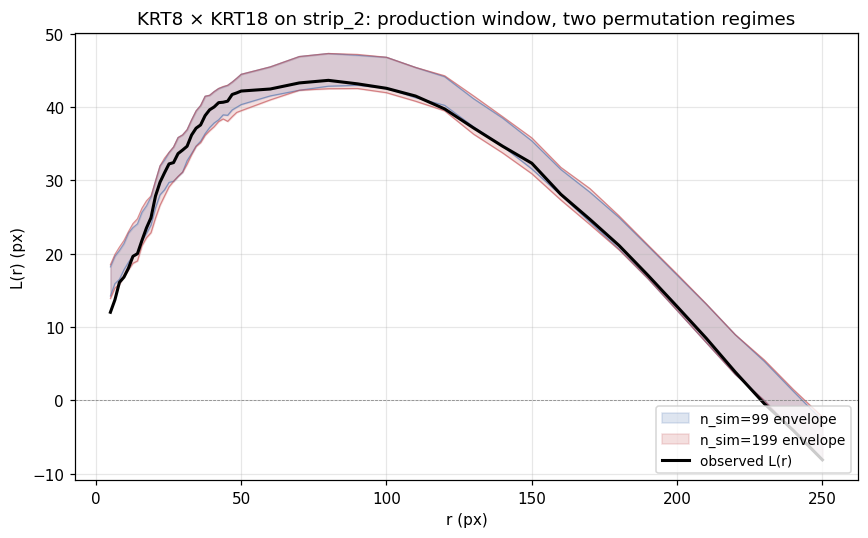

Saved → ..\results\figures\13_positive_anchor_retest.png


In [7]:
PALETTE = {99: '#4C72B0', 199: '#C44E52'}

fig, ax = plt.subplots(figsize=(8, 5))

for n_sim, env in envelopes.items():
    color = PALETTE[n_sim]
    ax.fill_between(
        r_vals, env['l_lo'], env['l_hi'],
        color=color, alpha=0.18,
        label=f'n_sim={n_sim} envelope',
    )
    ax.plot(r_vals, env['l_hi'], color=color, lw=0.8, alpha=0.6)
    ax.plot(r_vals, env['l_lo'], color=color, lw=0.8, alpha=0.6)

ax.plot(r_vals, l_obs, color='black', lw=2.0, label='observed L(r)')
ax.axhline(0, color='grey', lw=0.5, ls='--')

# Mark radii where l_obs exceeds each envelope
y_obs_max = l_obs.max()
for i, n_sim in enumerate(N_SIM_VALUES):
    above = l_obs > envelopes[n_sim]['l_hi']
    if above.any():
        y = y_obs_max * (1.08 + 0.05 * i)
        ax.scatter(r_vals[above], np.full(above.sum(), y),
                   color=PALETTE[n_sim], marker='|', s=80,
                   label=f'exceeds n_sim={n_sim} envelope')

ax.set_xlabel('r (px)')
ax.set_ylabel('L(r) (px)')
ax.set_title(f'{GENE_A} × {GENE_B} on {STRIP}: production window, '
             f'two permutation regimes')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()

out_path = FIGS / '13_positive_anchor_retest.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## 6. Verdict

Read off the result from section 4 and fill in the matching branch:

**Branch C.1 — both `n_sim` values pass:** The production envelope is fine. The empty network in nb12 is *not* a power problem; the CellChatDB panel simply doesn't co-cluster strongly. Proceed to revival plan Step B (extended panel) and Step A.5 (effect-size network).

**Branch C.2 — only `n_sim=99` passes:** The production envelope was over-strict. Re-run the full 438-pair HPC batch at `n_sim=99` (revival plan Step C.2). This is the path most likely to deliver criteria 1, 2 *and* 3.

**Branch C.3 — neither passes:** The production window or edge-correction has lost sensitivity relative to nb04. Investigate the window comparison (nb09c) and the edge-correction bias (nb09) before doing anything else; this would be a more serious finding than the n_sim question.

_(Write the chosen branch + supporting numbers here once the cells above have been executed.)_

## 7. Negative-control sanity check: MALAT1 × KRT18

The section 5 plot showed `l_obs` sitting inside both envelopes for KRT8 × KRT18, with a characteristic dome shape that is *also present in the envelope*. The dome is the lung tissue itself: every transcript on this strip is concentrated in epithelial regions, so any two transcripts will look "co-clustered" at the tissue's characteristic scale (~ 80 px) relative to a uniform-on-window null. The all-pool permutation test correctly captures this — the envelope tracks the dome — and concludes KRT8 and KRT18 are no more co-clustered than any other pair of tissue-confined points on this strip.

This is correct behaviour but raises a worry: **has the concave hull flattened the test to the point that nothing exceeds the envelope?** We can rule that out cheaply by running a pair with genuinely *different* spatial supports.

**MALAT1 × KRT18** is the cleanest negative anchor available:
- MALAT1 is a nuclear lncRNA, broadly expressed across cell types, so its transcripts are diffusely distributed across the tissue.
- KRT18 is tightly tissue-confined (cytokeratin in simple epithelium).
- Their spatial distributions differ. The permutation test should produce `l_obs` clearly *below* the envelope midline — a negative SES that's distinguishable from KRT8 × KRT18's near-zero SES.

If we see that separation, the test discriminates and we can pivot to **effect-size ranking** (revival plan Step A.5) for the network — building edges from pairs that sit *highest* within their envelopes, even if none formally exceed them. If we don't see it, the window or null is too aggressive and needs revision before any further analysis.

In [8]:
GENE_NEG = 'MALAT1'

coords_neg = get_coords(strip_df, GENE_NEG)
print(f'{GENE_NEG}: {len(coords_neg):,} transcripts on {STRIP}')

# Reuse the same window + r_vals as the positive control.
# max_n + seed must match between bivariate_k (observed) and compute_envelope
# so both see the same subsampled subset of MALAT1 transcripts.
k_obs_neg = bivariate_k(
    coords_neg, coords_b, r_vals, window,
    resolution=RESOLUTION,
    max_n=MAX_N, seed=SEED,
)
l_obs_neg = k_to_l(k_obs_neg, r_vals)

# One envelope is enough — Section 3 showed n_sim=99 and n_sim=199 are equivalent
print(f'  computing envelope at n_sim=99 (max_n={MAX_N}) ...', end=' ', flush=True)
l_lo_neg, l_hi_neg = compute_envelope(
    coords_neg, coords_b, r_vals, window,
    n_sim=99, seed=SEED, resolution=RESOLUTION,
    max_n=MAX_N,
)
print('done')

# Peak signed SES (same formula as nb12) for both pairs, for direct comparison
def peak_signed_ses(l_obs_arr, l_lo_arr, l_hi_arr):
    mid  = (l_hi_arr + l_lo_arr) / 2
    half = (l_hi_arr - l_lo_arr) / 2
    ses  = np.where(half > 1e-9, (l_obs_arr - mid) / half, 0.0)
    return float(ses[int(np.argmax(np.abs(ses)))])

ses_pos = peak_signed_ses(l_obs,     envelopes[99]['l_lo'], envelopes[99]['l_hi'])
ses_neg = peak_signed_ses(l_obs_neg, l_lo_neg,              l_hi_neg)

print()
print('Peak signed SES (units: envelope half-widths from midline):')
print(f'  KRT8   × KRT18  (expected co-localised): {ses_pos:+.2f}')
print(f'  MALAT1 × KRT18  (expected anti-correl.): {ses_neg:+.2f}')
print()
print(f'Separation: {ses_pos - ses_neg:+.2f}')
print('Test discriminates if the negative-control SES is meaningfully lower '
      'than the positive-control SES.')

MALAT1: 16,808 transcripts on strip_2
  computing envelope at n_sim=99 (max_n=3000) ... done

Peak signed SES (units: envelope half-widths from midline):
  KRT8   × KRT18  (expected co-localised): -2.18
  MALAT1 × KRT18  (expected anti-correl.): -4.85

Separation: +2.67
Test discriminates if the negative-control SES is meaningfully lower than the positive-control SES.


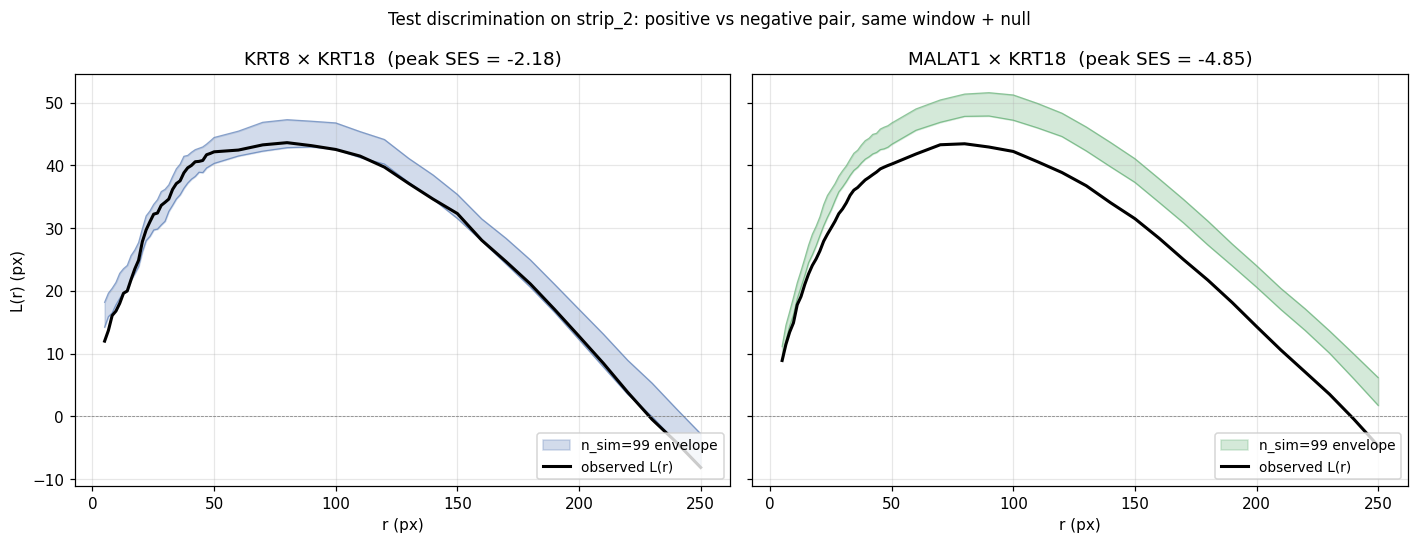

Saved → ..\results\figures\13_pos_vs_neg_sanity.png


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Left: KRT8 × KRT18 (positive control)
ax1.fill_between(r_vals, envelopes[99]['l_lo'], envelopes[99]['l_hi'],
                 color='#4C72B0', alpha=0.25, label='n_sim=99 envelope')
ax1.plot(r_vals, envelopes[99]['l_hi'], color='#4C72B0', lw=0.8, alpha=0.6)
ax1.plot(r_vals, envelopes[99]['l_lo'], color='#4C72B0', lw=0.8, alpha=0.6)
ax1.plot(r_vals, l_obs, color='black', lw=2.0, label='observed L(r)')
ax1.axhline(0, color='grey', lw=0.5, ls='--')
ax1.set_xlabel('r (px)')
ax1.set_ylabel('L(r) (px)')
ax1.set_title(f'KRT8 × KRT18  (peak SES = {ses_pos:+.2f})')
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(alpha=0.3)

# Right: MALAT1 × KRT18 (negative control)
ax2.fill_between(r_vals, l_lo_neg, l_hi_neg,
                 color='#55A868', alpha=0.25, label='n_sim=99 envelope')
ax2.plot(r_vals, l_hi_neg, color='#55A868', lw=0.8, alpha=0.6)
ax2.plot(r_vals, l_lo_neg, color='#55A868', lw=0.8, alpha=0.6)
ax2.plot(r_vals, l_obs_neg, color='black', lw=2.0, label='observed L(r)')
ax2.axhline(0, color='grey', lw=0.5, ls='--')
ax2.set_xlabel('r (px)')
ax2.set_title(f'MALAT1 × KRT18  (peak SES = {ses_neg:+.2f})')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle(f'Test discrimination on {STRIP}: positive vs negative pair, '
             f'same window + null',
             fontsize=11)
plt.tight_layout()

out_path = FIGS / '13_pos_vs_neg_sanity.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

### What to look for

Three possible outcomes, in decreasing order of preference:

**Outcome 1 — clean separation, negative SES is meaningfully lower (e.g. ≤ −1).** The test discriminates between co-localised and anti-correlated pairs even on the tight concave hull. KRT8 × KRT18's near-zero SES is a real "no excess co-clustering" signal rather than test failure. **Next move: revival plan Step A.5** — build the network on top-N pairs ranked by SES across the existing 438-row HPC output. This is a defensible criterion-1 result regardless of formal significance.

**Outcome 2 — moderate separation (negative SES ≈ −0.5 to −1).** The test discriminates weakly. Effect-size ranking is still useable, but consider also running revival plan Step A.4 (global rank envelope / area-above-envelope test) which pools information across radii and may recover separation that the pointwise peak-SES blurs.

**Outcome 3 — no separation, negative SES near zero or positive.** The window has flattened the test for *any* pair on this strip — the per-tissue inhomogeneity is dominating everything. **Stop and reconsider the null.** Options to investigate next:
- An inhomogeneous K-function (`Kinhom`) which estimates intensity from the data and divides it out, so the test asks "given the background density structure, is there *additional* co-clustering?"
- A restricted permutation pool (e.g. permute labels only among epithelial markers) so the null reflects "structured-in-tissue" rather than "uniform-on-window".

Fill in the observed numbers and chosen branch below once the cells above have been executed.